# Example-05: FFRFT/ZOOM amplitude spectrum

In [1]:
# Import

import numpy
import torch
import nufft
import yaml

import sys
sys.path.append('..')

from harmonica.util import LENGTH
from harmonica.statistics import weighted_mean, weighted_variance
from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.filter import Filter

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())
print(torch.get_num_threads())

False
8


In [2]:
# Set data type and device

dtype = torch.float64
device = torch.device('cpu')

Window(1024, 'cosine_window', 1.0)
Data(64, Window(1024, 'cosine_window', 1.0))
Frequency(Data(64, Window(1024, 'cosine_window', 1.0)), f_range=(0.0, 0.5))
tensor([1.191406250000e-01, 1.210918426514e-01], dtype=torch.float64)
tensor([1.191406250000e-01, 1.210937500000e-01], dtype=torch.float64)
tensor([1.191406250000e-01, 1.210937500000e-01], dtype=torch.float64)


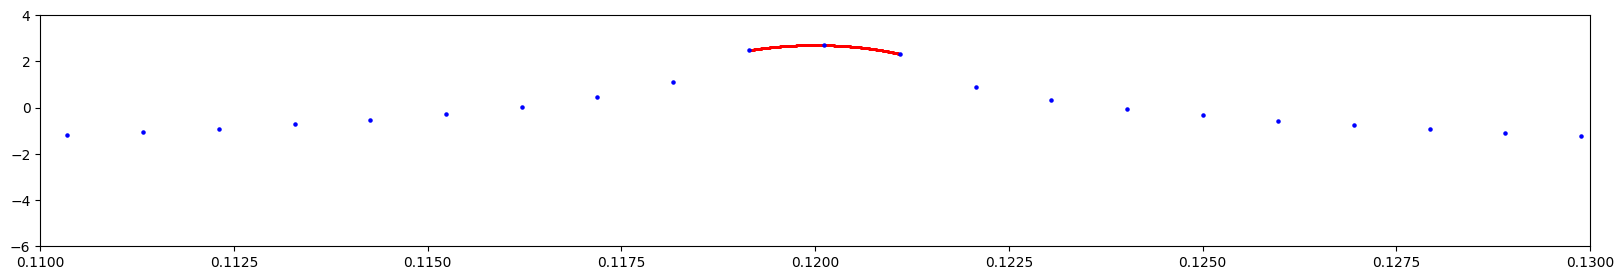

tensor([1.150000000000e-01, 1.249902343750e-01], dtype=torch.float64)
tensor([1.150000000000e-01, 1.250000000000e-01], dtype=torch.float64)


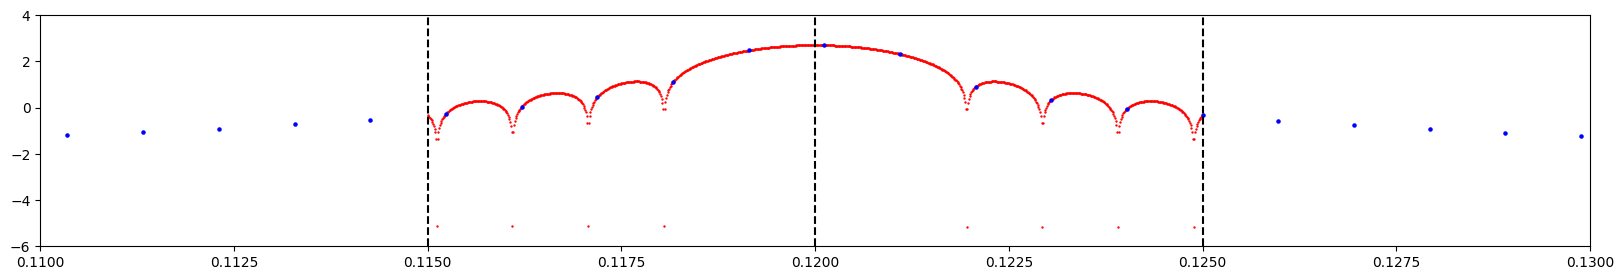

In [3]:
# FFRFT can be used for local DTFT spectrum interpolation

# Set parameters (64 signals with length 1024)

size, length = 64, 1024

# Set window

w = Window.from_cosine(length, order=1.0, dtype=dtype, device=device)
print(w)

# Set TbT data (64 signals with two components and different amplitudes)

t = torch.linspace(1.0, length, length, dtype=dtype, device=device)
data = torch.stack([i*torch.sin(2.0*numpy.pi*1*0.12*t) + 0.01*i*torch.sin(2.0*numpy.pi*2*0.12*t) for i in range(1, size + 1)])
d = Data.from_data(w, data)
print(d)

# Initialize Frequency instance

f = Frequency(d)
print(f)

# Apply window (note, window is applied to work)

d.window_remove_mean()
d.window_apply()

# Compute FFT amplitude spectrum

f.fft_get_spectrum()

# By default for FFRFT spectrum, FFT frequency estimation is used
# And frequency range is equal to 2 FFT bins around max FFT bin
# This can be changed by setting fraction parameter on initialization
# Or by setting ffrft_span attibute directry after initialization
# Use default value.

f.ffrft_span = 2.0/f.length

# If ffrft_flag is False, ffrft_initialize_spectrum is invoked
# ffrft_flag is set to True, futher calls do not reinitialize FFRFT
# No need to initialize for fixed signal length

# Compute FFT frequency estimation (used to define FFRFT frequency center)

f.fft_get_frequency()

# Compute FFRFT amplitude spectrum

f.ffrft_get_spectrum()

# Note, last point is not included

print(torch.stack([f.ffrft_get_grid(0)[0], f.ffrft_get_grid(0)[-1]]))
print(torch.stack([f.ffrft_get_grid(0)[0], f.ffrft_get_grid(0)[-1] + f.ffrft_span*f.fft_step]))
print(torch.stack([f.fft_frequency[0] - f.fft_step, f.fft_frequency[0] + f.fft_step]))

# Plot (log10) FFT spectrum for given signal id

idx = 0
plt.figure(figsize=(20, 3))
plt.scatter(f.ffrft_get_grid(idx).cpu(), torch.log10(f.ffrft_spectrum[idx].cpu()), s=0.5, c='r')
plt.scatter(f.fft_grid.cpu(), torch.log10(f.fft_spectrum[idx].cpu()), s=5.0, c='b')
plt.xlim(0.12 - 0.01, 0.12 + 0.01)
plt.ylim(-6.0, 4.0)
plt.show()

# FFRFT can be used with custom range
# In this case all signals share this range, while for the default case, each signal range is defined by its FFT frequency
# In all cases range length is the same for all signals

# Compute FFRFT amplitude spectrum with custom range
# Range (f_min, f_max) = (center - 0.5*span, center + 0.5*span - span/length)

f.ffrft_get_spectrum(center=0.12, span=0.01)

# Note, last point is not included

print(torch.stack([f.ffrft_get_grid(0)[0], f.ffrft_get_grid(0)[-1]]))
print(torch.stack([f.ffrft_get_grid(0)[0], f.ffrft_get_grid(0)[-1] + f.ffrft_span*f.fft_step]))

# Plot (log10) FFT spectrum for given signal id

idx = 0
plt.figure(figsize=(20, 3))
plt.scatter(f.ffrft_get_grid(idx).cpu().numpy(), torch.log10(f.ffrft_spectrum[idx]).cpu().numpy(), s=0.5, c='red')
plt.scatter(f.fft_grid.cpu().numpy(), torch.log10(f.fft_spectrum[idx]).cpu().numpy(), s=5.0, c='blue')
plt.xlim(0.12 - 0.01, 0.12 + 0.01)
plt.ylim(-6.0, 4.0)
plt.vlines(0.12, -6.0, 4.0, colors='black', linestyles='dashed')
plt.vlines(0.12 - 0.01/2, -6.0, 4.0, colors='black', linestyles='dashed')
plt.vlines(0.12 + 0.01/2, -6.0, 4.0, colors='black', linestyles='dashed')
plt.show()

# Clean

del w
del t, data
del d
del f
if device != torch.device('cpu'):
    torch.cuda.synchronize()
    torch.cuda.empty_cache()